<a href="https://colab.research.google.com/github/ArshiaSingh05/Platform-Identification-System-using-Acoustic-Signature/blob/main/DRDO_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas

In [ ]:
!pip install matplotlib seaborn glob2 ipython librosa numpy scipy soxr
# Before installing librosa we have to install other dependencies also because it has many dependencies in itself.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

from glob2 import glob
import librosa
import librosa.display
import IPython.display as ipd

from itertools import cycle

sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

In [ ]:
# from glob import glob

# Load all .wav files from dolphin, torpedo, and ship folders
# audio_files = glob("/content/audio_files.zip")
# print(audio_files)
#from google.colab import files
#uploaded = files.upload()
#import zipfile
#with zipfile.ZipFile("/content/audio_files.zip", 'r') as zip_ref:
 #   zip_ref.extractall("/content/audio_files")
#from glob import glob

#audio_files = glob("/content/audio_files/**/*/*.wav", recursive=True)
#print(f"Total audio files: {len(audio_files)}")
#print(audio_files[:5])  # see first 5 paths

In [ ]:
# LABEL = SHIP TYPE

# print(len(audio_files))

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
from IPython.display import Audio as ipdAudio
from glob import glob
path = "/content/drive/MyDrive/audio_files"
audio_files = glob(path + "/**/*.wav", recursive=True)
print(f"Total audio files found: {len(audio_files)}")
print(audio_files[:5])
ipdAudio(audio_files[50])


Total audio files found: 286
['/content/drive/MyDrive/audio_files/Submarine/deep-sea-ambience-6933_aug3.wav', '/content/drive/MyDrive/audio_files/Submarine/deep-sea-ambience-6933_aug2.wav', '/content/drive/MyDrive/audio_files/Submarine/deep-sea-ambience-6933_aug1.wav', '/content/drive/MyDrive/audio_files/Submarine/submarine-sonar-38243_aug1.wav', '/content/drive/MyDrive/audio_files/Submarine/submarine-prop-whooshing-45861_aug3.wav']


In [ ]:
!pip install librosa

In [ ]:
!pip show librosa

Name: librosa
Version: 0.11.0
Summary: Python module for audio and music processing
Home-page: https://librosa.org
Author: Brian McFee, librosa development team
Author-email: brian.mcfee@nyu.edu
License: ISC
Location: /usr/local/lib/python3.11/dist-packages
Requires: audioread, decorator, joblib, lazy_loader, msgpack, numba, numpy, pooch, scikit-learn, scipy, soundfile, soxr, typing_extensions
Required-by: 


In [ ]:
import librosa

In [ ]:
#pip install --upgrade paramiko cryptography


In [ ]:
pip install cryptography==42.0.8


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 51.6 MB/s eta 0:00:00
  Attempting uninstall: cryptography
    Found existing installation: cryptography 43.0.3
    Uninstalling cryptography-43.0.3:
      Successfully uninstalled cryptography-43.0.3


In [ ]:
!pip show cryptography
!pip show pyopenssl



Name: cryptography
Version: 42.0.8
Summary: cryptography is a package which provides cryptographic recipes and primitives to Python developers.
Home-page: https://github.com/pyca/cryptography
Author: 
Author-email: The Python Cryptographic Authority and individual contributors <cryptography-dev@python.org>
License: Apache-2.0 OR BSD-3-Clause
Location: /usr/local/lib/python3.11/dist-packages
Requires: cffi
Required-by: PyDrive2, pyOpenSSL, SecretStorage
Name: pyOpenSSL
Version: 24.2.1
Summary: Python wrapper module around the OpenSSL library
Home-page: https://pyopenssl.org/
Author: The pyOpenSSL developers
Author-email: cryptography-dev@python.org
License: Apache License, Version 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: cryptography
Required-by: PyDrive2


In [ ]:
y, sr = librosa.load(audio_files[48])
# y -> raw data of the audio file
# sr -> sampling rate of the audio file

In [ ]:
print(f'y: {y[:10]}')
print(f'y shape: {y.shape}')
print(f'sr: {sr}')

y: [ 0.00307072  0.00128744 -0.00113036  0.00070647 -0.00259896 -0.00040803
  0.00066432 -0.00191343  0.00093411  0.00025209]
y shape: (1015006,)
sr: 22050


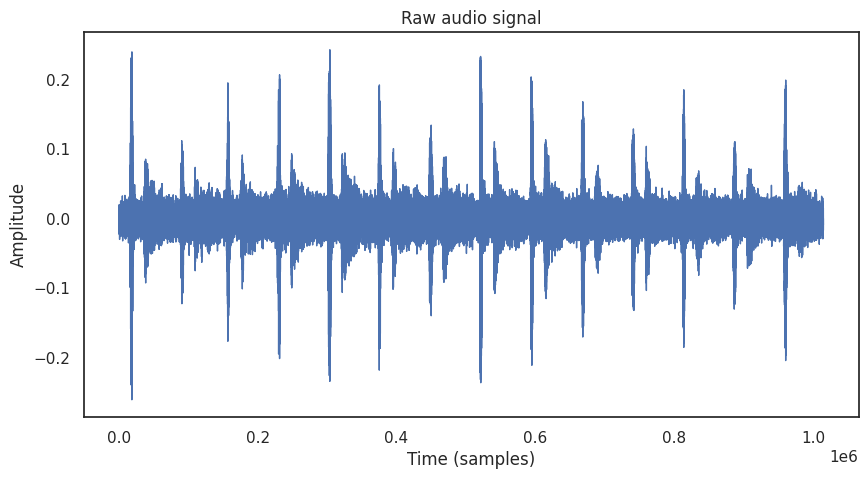

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="white")
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
pd.Series(y).plot(figsize=(10, 5),lw = 1,color = color_pal[0])
plt.title('Raw audio signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()

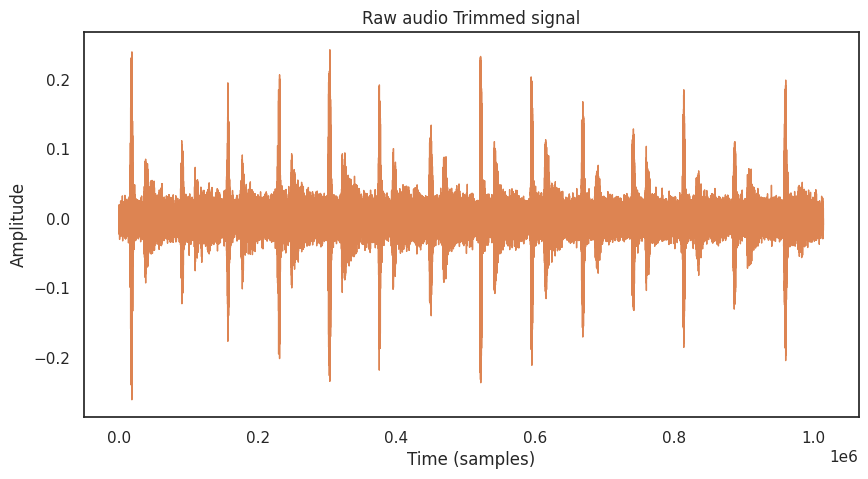

In [ ]:
y_trimmed, _ = librosa.effects.trim(y,top_db=20)
#  help to trim(remove) empty spaces...plane lines
pd.Series(y).plot(figsize=(10, 5),lw = 1,color = color_pal[1])
plt.title('Raw audio Trimmed signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()

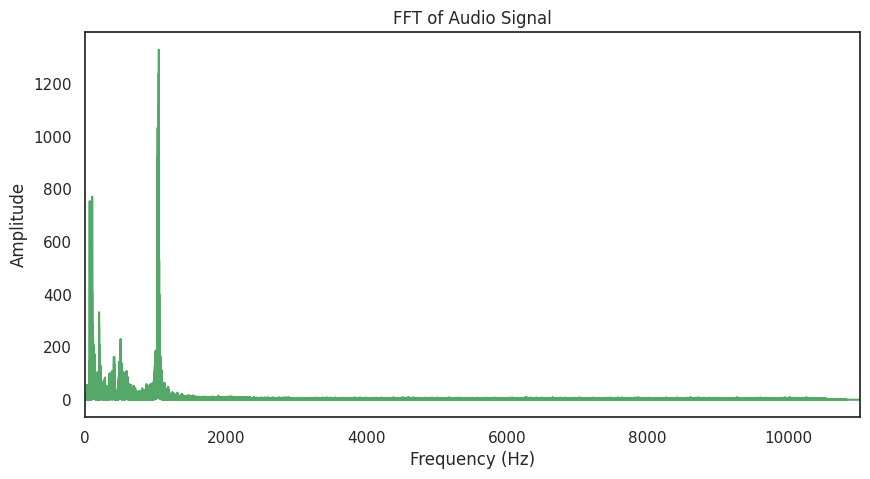

In [ ]:
# Compute the Fast Fourier Transform (FFT) of the audio signal
# This will convert the time-domain signal into the frequency domain.
# The FFT is a powerful algorithm to compute the Discrete Fourier Transform (DFT) and its inverse.
fft_vals = np.fft.fft(y)
fft_freq = np.fft.fftfreq(len(fft_vals), 1/sr)

# Only take the positive frequencies
pos_mask = fft_freq >= 0
fft_freq = fft_freq[pos_mask]
fft_power = np.abs(fft_vals[pos_mask])

plt.figure(figsize=(10, 5))
plt.plot(fft_freq, fft_power, color=color_pal[2])
plt.title('FFT of Audio Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim([0, sr/2])
plt.show()

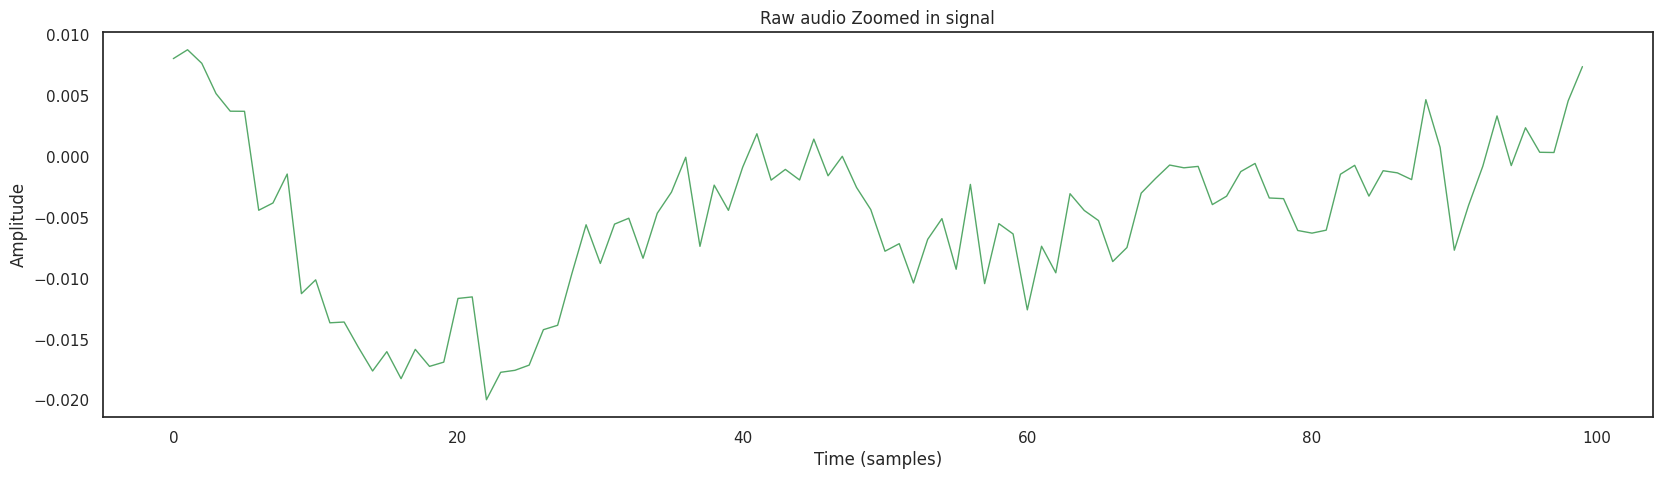

In [ ]:
pd.Series(y[2000:2100]).plot(figsize=(20, 5),lw = 1,color = color_pal[2])
plt.title('Raw audio Zoomed in signal')
plt.xlabel('Time (samples)')
plt.ylabel('Amplitude')
plt.show()


In [ ]:
# Calculate average power (mean of squared amplitude)
avg_power = np.mean(fft_power ** 2)

# Intensity is often proportional to power for audio signals
avg_intensity = avg_power

# Sample rate is already given by sr
avg_sample_rate = sr

# Loudness can be estimated as the mean dB value of the FFT power (avoid log(0) by adding small epsilon)
epsilon = 1e-10
loudness_db = 10 * np.log10(fft_power + epsilon)
avg_loudness = np.mean(loudness_db)

print(f"Average Power: {avg_power}")
print(f"Average Intensity: {avg_intensity}")
print(f"Sample Rate: {avg_sample_rate}")
print(f"Average Loudness (dB): {avg_loudness}")

Average Power: 591.7537841796875
Average Intensity: 591.7537841796875
Sample Rate: 22050
Average Loudness (dB): 3.3747034072875977


In [ ]:
# Compute the Short-Time Fourier Transform (STFT)
# This will give us a time-frequency representation of the audio signal
trans = librosa.stft(y)
spect_db = librosa.amplitude_to_db(np.abs(trans), ref=np.max)
spect_db.shape

(1025, 1983)

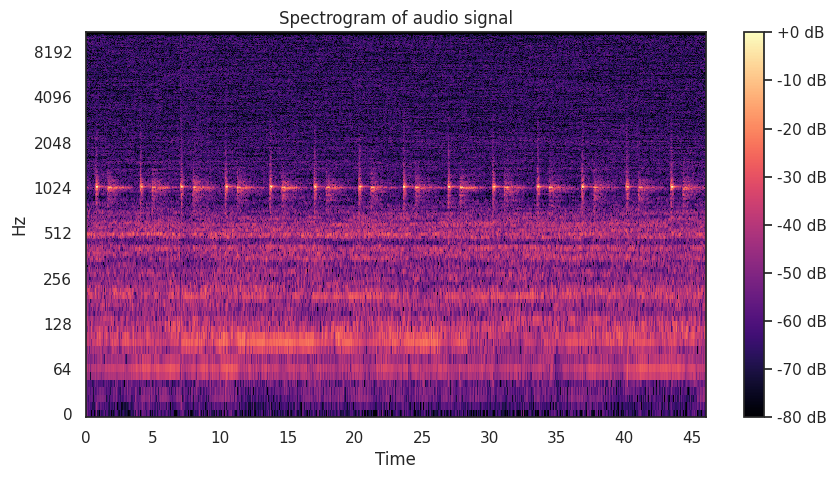

In [ ]:
# Plot the transformed audio data
fig , ax = plt.subplots(figsize=(10, 5))
img = librosa.display.specshow(spect_db,x_axis='time', y_axis='log', ax=ax)
ax.set_title('Spectrogram of audio signal')
fig.colorbar(img, ax=ax, format="%+2.f dB")

Mel Spectrogram

In [ ]:
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.amplitude_to_db(S, ref=np.max)

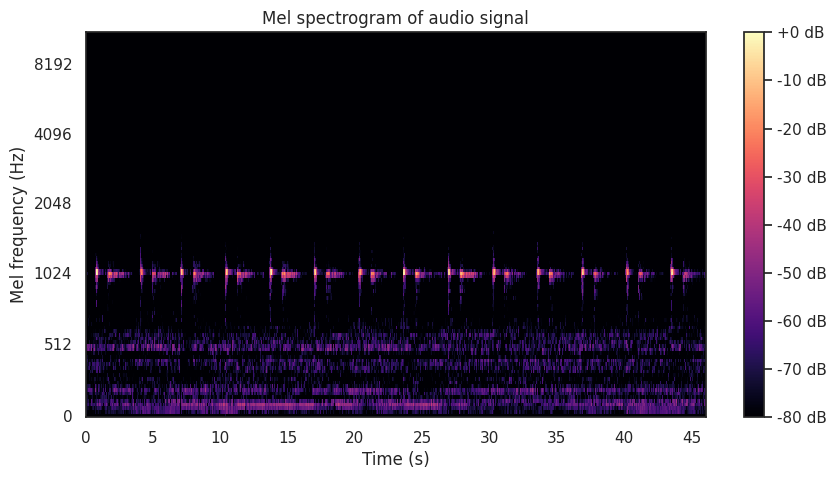

In [ ]:
fig,ax =  plt.subplots(figsize=(10, 5))
plt.title('Mel spectrogram of audio signal')
# plot the mel spectrogram

img = librosa.display.specshow(S_dB, x_axis='time', y_axis='mel', sr=sr)
plt.colorbar(img, format="%+2.f dB")
plt.xlabel('Time (s)')
plt.ylabel('Mel frequency (Hz)')
plt.show()

--Data Preprocessing--

In [ ]:
import os
import numpy as np
from glob import glob
import librosa
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


Step-1: Getting File Paths and Labels

In [ ]:
# Path to your dataset
base_path = "/content/drive/MyDrive/audio_files"

# Get all .wav files from all subfolders
audio_files = glob(base_path + "/*/*.wav")

# Extract labels (folder names like dolphin, torpedo, ship)
labels = [file.split("/")[-2] for file in audio_files]

# Encode string labels to integers
le = LabelEncoder()
encoded_labels = le.fit_transform(labels)

print("Classes:", le.classes_)  # Output: ['dolphin' 'ship' 'torpedo']


Classes: ['Submarine' 'Torpedo' 'Torpedo_augmented' 'dolphins']


Step-2: Define a Function to Extract Features (e.g., MFCC)

In [ ]:
def extract_features(file_path, max_pad_len=862):  # 862 = around 5 sec for 22050Hz
    try:
        audio, sample_rate = librosa.load(file_path, sr=22050)
        mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)

        # Padding or trimming to fixed length
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]

        return mfcc
    except Exception as e:
        print("Error processing", file_path, ":", e)
        return None

Step-3: Apply Feature Extraction on All Files

In [ ]:
features = []
final_labels = []

for i, file_path in enumerate(audio_files):
    mfcc = extract_features(file_path)
    if mfcc is not None:
        features.append(mfcc)
        final_labels.append(encoded_labels[i])


Step-4: Convert to NumPy Arrays for Model Input

In [ ]:
X = np.array(features)                     # Shape: (num_samples, 40, 862)
X = X[..., np.newaxis]                    # Add channel dimension for CNN: (samples, 40, 862, 1)
y = np.array(final_labels)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (286, 40, 862, 1)
y shape: (286,)


**Marine Acoustic Signature Classification using CRNN**

In [ ]:
!pip install tensorflow


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.utils import to_categorical
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)

In [ ]:
num_classes = len(np.unique(y_train))
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat  = to_categorical(y_test,  num_classes=num_classes)

# Optional: human‑readable class names (edit to your real labels)
class_names = [f"class_{i}" for i in range(num_classes)]

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(40, 862, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 38, 860, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 38, 860, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 19, 430, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 17, 428, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 17, 428, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 214, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 109568)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    14,024,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,044,548 (53.58 MB)

 Trainable params: 14,044,356 (53.57 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
# --------------------- 5. Callbacks ---------------------
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_cnn.h5", save_best_only=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]


Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.6666 - loss: 33.2278 - val_accuracy: 0.9310 - val_loss: 0.9495
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.8137 - loss: 1.9863 - val_accuracy: 0.9483 - val_loss: 0.1882
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8900 - loss: 0.5245 - val_accuracy: 0.9310 - val_loss: 0.1864
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9356 - loss: 0.1800 - val_accuracy: 0.9655 - val_loss: 0.0902
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9453 - loss: 0.1127 - val_accuracy: 0.9655 - val_loss: 0.1300
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9651 - loss: 0.1147 - val_accuracy: 0.9310 - val_loss: 0.1042
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.9547 - loss: 0.0825 - val_accuracy: 0.9655 - val_loss: 0.1153
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.9868 - loss: 0.0377 - val_accuracy: 0.9655 - val_loss: 0.1408
Epoch 9

In [ ]:
file_path = '/content/drive/MyDrive/audio_files/testing_audio003.wav'

# Extract features like before
test_mfcc = extract_features(file_path)
test_mfcc = test_mfcc[np.newaxis, ..., np.newaxis]  # shape (1, 40, 862, 1)

# Make prediction
pred = model.predict(test_mfcc)
pred_class = np.argmax(pred)

# Decode class label
pred_label = le.inverse_transform([pred_class])[0]

# Print result with confidence
confidence = pred[0][pred_class] * 100
print(f"I am {confidence:.2f}% sure this is the sound of a '{pred_label}'.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
I am 100.00% sure this is the sound of a 'dolphins'.
